<a href="https://colab.research.google.com/github/uttamtyagi95/MACHINE-LEARNING/blob/main/project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [ ]:
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df=pd.read_csv('Mall_Customers.csv')

In [ ]:
print(df.shape)
print(df.info)
print(df.describe)

(200, 5)
<bound method DataFrame.info of      CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]>
<bound method NDFrame.describe of      CustomerID  Gender 

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
import plotly.express as px
fig = px.pie(
    df,
    names='Gender',
    title='Gender Ditribution of Customers',
    hole=0.4,
    width=800,
    height=600,
)
fig.show()

In [ ]:
fig=px.histogram(
    df,x='Age',
    nbins=15,
title='Age distribution of customers',
marginal='box',
width=800,
height=600
)
fig.show()

In [ ]:
fig = px.histogram(
df,
x='Annual Income (k$)',
nbins=15,
title='Annual income Distribution',
marginal='box',
width=800,
height=600
)
fig.show()

In [ ]:
fig=px.scatter(
    df,
    x='Age',
    y='Spending Score (1-100)',
    color='Gender',
    title='Age vs Spending score',
    width=800,
    height=600
)
fig.show()

In [ ]:
fig=px.scatter(
    df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    color='Gender',
    title='Age vs Spending score',

)
fig.update_traces(marker=dict(size=10))
fig.show()

In [ ]:
df["Gender"]=df["Gender"].map({'Male':1,'Female':0})

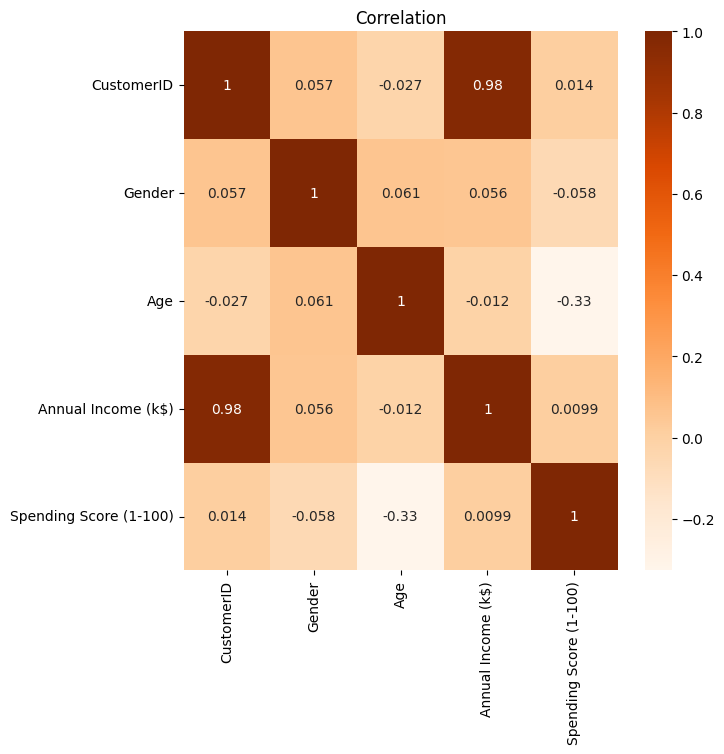

In [ ]:
corr=df.corr()
plt.figure(figsize=(7,7))
sns.heatmap(corr,annot=True,cmap='Oranges')
plt.title("Correlation")
plt.show()

In [ ]:
from sklearn.cluster import KMeans
kmeans=KMeans(
n_clusters=5,
random_state=42,
n_init=10
)

df["Cluster"]=kmeans.fit_predict(
    df[["Annual Income (k$)","Spending Score (1-100)"]]
)

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,1,19,15,39,4
1,2,1,21,15,81,2
2,3,0,20,16,6,4
3,4,0,23,16,77,2
4,5,0,31,17,40,4


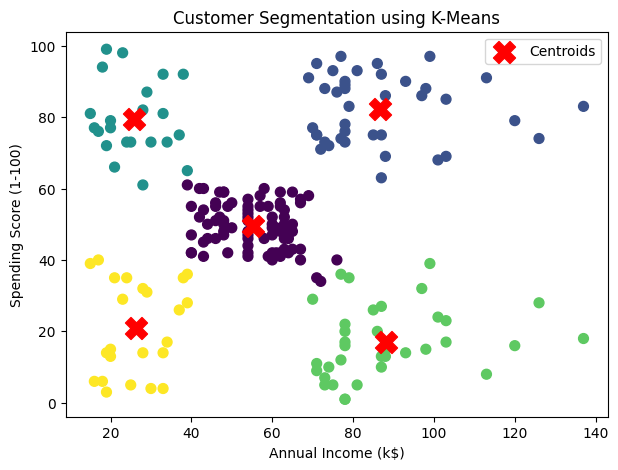

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    s=50
)
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    marker='X',
    s=250,
    color='red',
    label='Centroids'
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.show()

In [ ]:
import plotly.express as px
fig = px.scatter_3d(
    df,
    x='Age',
    y='Annual Income (k$)',
    z='Spending Score (1-100)',
    color='Gender',   # Optional
    title='3D Customer Distribution',
    width=900,
    height=700
)
fig.show()